# SVC - More Kernels

### 1. Introduction

In the last notebook, we introduced a custom kernel that was equivalent to the explict transformation we could perform on our data to make it linearly separable. Our custom kernel was of the form, 

$$
K(X_i, X_j) = X_i X_j^T + (X_i X_i^T)(X_j X_j^T)
$$

This was the same as the explicity transformation $X_i = [X_{i1}, X_{i2}] \Longrightarrow \phi(X_i) = [X_{i1}, X_{i2}, X_{i1}^2 + X_{i2}^3]$ which essentially added an extra dimension $X_{i3} = X_{i1}^2 + X_{i2}^3$ to the data. When working with real-life data, we often select a kernel from a list of commonly used kernels rather than create a custom kernel for the problem. Of course, if we can define a custom kernel that accurately captures the relationships or nonlinearities in our data, it can lead to significantly better model performance. However, in practice, we usually begin with the standard kernels such as the linear, polynomial, or RBF (Gaussian) kernels as these tend to work well for a wide range of problems and are computationally efficient.

### 2. The Polynomial Kernel

The polynomial kernel is one of the most common kernels used in SVC problems. It is defined as follows,

$$
K(X_i, X_j) = (X_i X_j^T + c)^d
$$

In which, $d$ is the degree of the kernel and $c \geq 0$ is a parameter which controls the influence of higher-order versus lower-order terms in the polynomial. The motivation for the polynomial kernel is that is corresponds to an explicit transformation of the original data $\phi (X_i)$ which contains so-called interaction terms of the features. Say that $X_i = [X_{i1}, X_{i2}]$, the interaction and higher-order terms in this case are $X_{i1}X_{i2}, X_{i1}^2$ and $X_{i2}^2$. We can show that these terms are present when rewriting the polynomial kernel with $d=2$ and $c=1$ as a dot product of vectors, 


$$
K(X_i, X_j) = (X_i X_j^T + 1)^2
$$

$$
= (X_i X_j^T + 1)(X_i X_j^T + 1)
$$

$$
= (X_i X_j^T)^2 + 2(X_i X_j^T) + 1
$$

$$
= (X_{i1}X_{j1} + X_{i2}X_{j2})^2 + 2(X_{i1}X_{j1} + X_{i2}X_{j2}) + 1
$$

$$
= X_{i1}^2 X_{j1}^2 + X_{i2}^2 X_{j2}^2 + 2 X_{i1}^2 X_{j1}X_{i2}X_{j2} + 2 X_{i1}X_{j1} + 2 X_{i2}X_{j2} + 1
$$

$$
=
\begin{bmatrix}
1 & \sqrt{2}X_{i1} & \sqrt{2}X_{i2} & \sqrt{2}X_{i1}X_{i2} & X_{i1}^2 & X_{i2}^2
\end{bmatrix}
\begin{bmatrix}
1 \\ \sqrt{2}X_{j1} \\ \sqrt{2}X_{j2} \\ \sqrt{2}X_{j1}X_{j2} \\ X_{j1}^2 \\ X_{j2}^2
\end{bmatrix}
= \phi(X_i) \phi(X_j)^T
$$

We can see that the kernel $K(X_i, X_j) = (X_i X_j^T + 1)^2$ corresponds to the explicit transformation $X_i = [X_{i1}, X_{i2}] \Longrightarrow \phi(X_i) = [1, \sqrt{2}X_{i1}, \sqrt{2}X_{i2}, \sqrt{2}X_{i1}X_{i2}, X_{i1}^2, X_{i2}^2]$. In theory, the addition of interaction terms which are non-linear should allow our model to capture more rich and complex relationships in our data. Generally, the polynomial kernel of degree $d$ is equivalent to an explicit transformation that maps data points $X_i$ to feature vectors $\phi(X_i)$ containing all interaction and higher-order terms up to the $d$-th degree. Taken from _"Kernel methods in machine learning"_ by T. Hofmann et al. (page 10), the same statement is formally given as: 

**"The polynomial kernel of degree $d$ thus computes a dot product in the space spanned by all monomials of degree $d$ in the input coordinates."**

A textbook result is that given the original data $X_i$ has $M$ number of features, the dimensions of the explicitly transformed counterpart by the polynomial kernel of degree $d$ is given by,

$$
\text{dim}[\theta(\phi(X_i))] = \sum_{k=0}^{d} \frac{(M+k-1)!}{k!(M-1)!}
$$

See _Schölkopf & Smola (2002) — Learning with Kernels_ for reference.

### 3. RBF Kernel

### 4. Implementation

Creating an implementation of the polynomial kernel is straight-forward. Given that the linear kernel calculated via $K = \text{np.dot}(X_i, X_j)$ using NumPy, the polynomial kernel is $K_{poly} = (K + c)^d$. However, it is slighty more involved to create the associated kernel matrix $\textbf{K}_{poly}$. Let $\textbf{K}$ be the linear kernel matrix whose elements are $K_{ij}$, the polynomial kernel matrix is computed by,

$$
\textbf{K}_{poly} = (\textbf{K} + c\mathbf{1}_{N \times N})^d
$$

In which, $\mathbf{1}_{N \times N}$ is a square matrix of size $N$ (number of samples) filled with ones. Note that $\textbf{K} = \text{np.dot(X, X.T)}$ using NumPy.

In [109]:
# Dependencies,
import numpy as np
from cvxopt import matrix, solvers

class BaseSVC:
    """Class for the support vector classifier (SVC)."""

    def __init__(self, C=1, kernel="linear", kernel_params=None):
        """Constructor method. Class attributes are created in this method."""

        # Model parameters,
        self.weights, self.bias = None, None
        self.label = "support vector classifier (soft-margin)"
        self.kernel, self.kernel_params = kernel, kernel_params
        self.fitted, self.scored = False, False
        self.C = C

        # Training data,
        self.X, self.y = None, None
        self.n_samples, self.n_features = None, None
        self.model_score = None

        # Related to the optimisation algorithm,
        self.Q_matrix = None
        self.alphas = None
        self.sv_idxs = None
        self.n_sv = None

    def fit(self, X, y):
        """Use this method to fit the model."""

        # Assigning data properties,
        self.X, self.y = X, np.where(y <= 0, -1, 1) # <-- Re-labeling class labels.
        self.n_samples, self.n_features = X.shape[0], X.shape[1]

        # Computing our Lagrangian multipliers,
        self.alphas = self._solve_dual_()

        # Computing model parameters,
        self.bias = np.mean([self.y[i] - self._decision_function(self.X[i], bias=False) for i in self.sv_idxs])

        # Update fitted state,
        self.fitted = True

    def predict(self, X):
        """This method returns the predictions when supplied with samples."""
        return np.array([np.sign(self._decision_function(X_i)).astype(int) for X_i in X])

    def score(self, X, y):
        """Computes the classification accuracy on the provided data."""

        # Re-labeling class labels,
        y = np.where(y <= 0, -1, 1)
        
        # Computing predictions,
        y_pred = self.predict(X)

        # Calculating classification accuracy,
        accuracy = np.mean(y_pred == y)
        self.model_score = accuracy
        self.scored = True

        return accuracy

    def _solve_dual_(self, verbose=False, epsilon=1e-5):
        """Finds the Lagrange multipliers which maximise the dual function for the hard-margin SVC."""

        # Constructing the Q matrix (weighted Gram matrix),
        self.Q_matrix = np.outer(self.y, self.y)*self._kernel_matrix(self.X)
        ones_vector = np.ones(self.n_samples, dtype=np.double)

        """Translating into CVXOPT formalism."""

        # Objective function,
        P_matrix_obj = matrix(self.Q_matrix.astype(np.double)) # <-- Wrapping the matrix  
        q_vector_obj = matrix(-1*ones_vector)

        # Constraint (1),
        G_std = -np.eye(self.n_samples)
        h_std = np.zeros(self.n_samples)

        G_slack = np.eye(self.n_samples)
        h_slack = np.ones(self.n_samples)*self.C

        G_object = matrix(np.vstack((G_std, G_slack)))
        h_object = matrix(np.hstack((h_std, h_slack)))

        # Constraint (2),
        A_object = matrix(self.y.reshape(1, -1).astype(np.double))
        b_object = matrix([0.0])

        # Solving,
        if not verbose:
            solvers.options['show_progress'] = False
        sol = solvers.qp(P=P_matrix_obj , q=q_vector_obj, G=G_object, h=h_object, A=A_object, b=b_object)
        alphas = np.asarray(sol["x"]).flatten() # <-- Extracting Lagrange multipliers.

        # Extracting support vectors,
        self.sv_idxs = np.where(alphas > epsilon)[0]
        self.n_sv = len(self.sv_idxs)

        return alphas

    def _decision_function(self, X, bias=True):
        """Returns the distance a sample is from the decision boundary in feature space."""
        self.kernel_vector = np.array([self._kernel_function(X, X_j) for X_j in self.X])
        return np.sum(self.alphas*self.y*self.kernel_vector) + self.bias if bias else np.sum(self.alphas*self.y*self.kernel_vector)
    
    def _compute_slack(self, epsilon_bound=1e-3):
        """Computes the slack variable for each training sample and its assoiated Lagrange multiplier. Returns a tuple."""

        # Computing the lagrange multipliers,
        slack_multipliers = self.C - self.alphas

        # Computing slack variables,
        slack_vars = np.zeros(shape=self.n_samples)
        mask = (self.alphas > self.C - epsilon_bound) & (self.alphas < self.C + epsilon_bound) # <-- We create a mask.
        selected_idxs = mask.nonzero()[0] # <-- Extracting indices where condition was met.
        for idx in selected_idxs:
            slack_vars[idx] = 1 - self.y[idx]*(np.dot(self.X[idx], self.weights) + self.bias)
        
        return slack_vars, slack_multipliers

    def _kernel_matrix(self, X):
        """Generates the kernel matrix of the data which is used to construct the Q-matrix."""

        if self.kernel == "linear":
            return np.dot(X, X.T)

        if self.kernel == "polynomial":

            # Extracting the kernel parameters,
            d, c = self.kernel_params[0], self.kernel_params[1]

            # Returning the kernel matrix,
            return (np.dot(X, X.T) + c) ** d

        if self.kernel == "custom":
            K = np.dot(X, X.T) # <-- Linear kernel matrix.
            return K + np.diag(K)[:, None] * np.diag(K)[None, :]

    def _kernel_function(self, X_i, X_j):
        """The kernel function of the SVC."""

        if self.kernel == "linear":
            return np.dot(X_i, X_j)
        
        if self.kernel == "polynomial":

            # Extracting the kernel parameters,
            d, c = self.kernel_params[0], self.kernel_params[1]

            # Returning kernel function,
            return (np.dot(X_i, X_j) + c)**d

        if self.kernel == "custom":
            return np.dot(X_i, X_j) + (np.dot(X_i, X_i) * np.dot(X_j, X_j))
    
    def _repr_html_(self):
        """Compact HTML GUI as the object representation in Jupyter Notebook."""
        html = f"""
        <div style="
            border:1px solid black;
            border-radius:6px;
            font-family:Arial, sans-serif;
            font-size:12px;
            line-height:1.2;
            width:fit-content;
            background:white;
            color:black;
            padding-left:8px;
            padding-right:8px;
        ">
            <!-- Title bar -->
            <i>{self.label}</i>
            <div style="
                background:#e0e0e0;
                padding:3px 6px;
                font-weight:bold;
                border-bottom:1px solid black;
                border-top-left-radius:6px;
                border-top-right-radius:6px;
                color:black;
            ">
                SVC
                <div style="margin-top:2px;">
                    <img src="svc_icon.png" alt="tree icon" width="30" height="30">
                </div>
            </div>

            <!-- Hyperparameters -->
            <ul style="margin:4px 0 4px 16px; padding:0;">
                <b>Hyperparameters:</b><br>
                self.C:</b> {self.C}<br>
                self.kernel:</b> {self.kernel}<br>
                self.kernel_params:</b> {self.kernel_params}<br>
            </ul>

            <!-- Divider -->
            <div style="
                border-top:1px solid #ccc;
                margin:4px 0;
            "></div>

            <!-- Status and other info -->
            <ul style="margin:4px 0 4px 16px; padding:0;">
        """

        if self.fitted:
            html += f"<b>Status:</b> <span style='color:green;'>Fitted</span>, <b>Score: </b>{round(self.model_score, 3) if self.scored == True else None} <br>"
            html += f"self.n_features:</b> {self.n_features}<br>"
            html += f"self.n_samples:</b> {self.n_samples}<br>"
            html += f"self.n_sv:</b> {self.n_sv}<br>"
        else:
            html += "<b>Status:</b> <span style='color:red;'>Not Fitted</span><br>"

        return html

# Dependencies,
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, resolution=10):

    # Define grid
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, resolution),
                           np.linspace(x2_min, x2_max, resolution))
    
    # Flatten grid and evaluate decision function
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    Z = np.array([model._decision_function(point) for point in grid])
    Z = Z.reshape(xx1.shape)

    return xx1, xx2, Z

Let us now test our kernels on the following synthetic dataset,

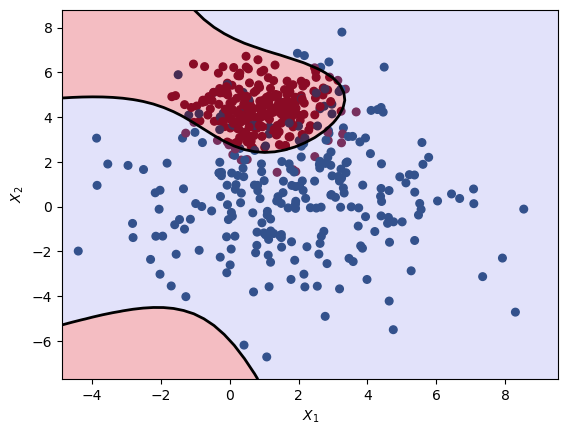

In [ ]:
# Importing,
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Creating dataset,
X, y = make_blobs(n_samples=500, centers=2, cluster_std=[1.0, 2.5], random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Training model,
clf = BaseSVC(kernel="polynomial", C=0.05, kernel_params=[3, 1])
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

# Plotting,
plt.scatter(X[:,0], X[:,1], c=y, cmap="RdBu", s=30)
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
xx1, xx2, Z = plot_decision_boundary(clf, X_train, resolution=50) # <-- Constructing decision boundary.
plt.contourf(xx1, xx2, Z, levels=[-np.inf, 0, np.inf], colors=["#8F7E7F","#A0A0F0"], alpha=0.3)
plt.contour(xx1, xx2, Z, levels=[0], colors='k', linewidths=2)  # decision boundary
plt.show()

# Model specs,
clf

### References 

https://en.wikipedia.org/wiki/Polynomial_kernel

https://www.youtube.com/watch?v=gEIXjG3f6vw